In [1]:
# Dataset citation: SDG Knowledge Hub Dataset of SDG-labeled News Articles, dataset file sdg_knowledge_hub.csv supplied in this repository. The CSV includes source article URLs and titles; no separate dataset publication citation was included. Dataset publisher/source identified by the folder as the SDG Knowledge Hub (International Institute for Sustainable Development).

In [ ]:
# Imports and simple EDA helpers
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_ROOT = Path("..")

def inspect_table(df, name, preview_columns=None):
    print(f"\n{name}: {len(df):,} rows x {len(df.columns):,} columns")
    cols = preview_columns or list(df.columns[:8])
    shown = df[cols]
    display(pd.DataFrame({"column": shown.columns, "dtype": [str(x) for x in shown.dtypes],
                          "missing": shown.isna().sum().values,
                          "missing_%": (shown.isna().mean().values * 100).round(2),
                          "unique": shown.astype(str).nunique(dropna=True).values}))
    print(f"Duplicate rows on shown columns: {shown.astype(str).duplicated().sum():,}")
    display(shown.head(5))

def plot_counts(counts, title, xlabel="Class", ylabel="Rows"):
    counts = counts.sort_index()
    display(counts.rename("count").to_frame())
    ax = counts.plot(kind="bar", figsize=(11, 4), color="#4472C4")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def text_stats(df, column):
    if column not in df.columns:
        return
    values = df[column].fillna("").astype(str)
    lengths = values.str.len()
    words = values.str.split().str.len()
    print(f"\nText field: {column}")
    display(pd.DataFrame({"characters": lengths.describe(), "words": words.describe()}))
    print("Empty text rows:", int(values.str.strip().eq("").sum()))

In [ ]:
# Load data
path = DATA_ROOT / "SDG Knowledge Hub Dataset of SDG-labeled News Articles/sdg_knowledge_hub.csv"
df = pd.read_csv(path, low_memory=False)
sdg_columns = [c for c in df.columns if c.startswith("SDG-")]

In [ ]:
# Table and missing values
inspect_table(df, "SDG Knowledge Hub", ["title", "type", "date", "sdgs", "text"])


SDG Knowledge Hub: 9,172 rows x 23 columns


,column,dtype,missing,missing_%,unique
0,title,object,0,0.00,9169
1,type,object,0,0.00,4
2,date,object,277,3.02,1519
3,sdgs,object,0,0.00,33
4,text,object,0,0.00,9171


Duplicate rows on shown columns: 0


,title,type,date,sdgs,text
0,UNECE Releases 44 Recommended Climate Indicato...,news,10 September 2021,7 SDGs,UNECE Releases 44 Recommended Climate Indicato...
1,Largest Source of Lead Pollution Phased Out in...,news,10 September 2021,2 SDGs,Largest Source of Lead Pollution Phased Out in...
2,VNR Update: 15 Countries Planning to Participa...,news,10 September 2021,Partnerships for the Goals,VNR Update: 15 Countries Planning to Participa...
3,SDG Moment Will Provide Reality Check with Nin...,news,9 September 2021,17 SDGs,SDG Moment Will Provide Reality Check with Nin...
4,"Biodiversity Framework Will Need Finance, Capa...",news,7 September 2021,Life on Land,"Biodiversity Framework Will Need Finance, Capa..."


In [ ]:
# Article type counts
display(df["type"].value_counts(dropna=False).to_frame("rows"))

,rows
type,
news,8312
guest_articles,500
policy_briefs,292
generation_30,68


,count
SDG-01,2562
SDG-02,1922
SDG-03,1949
SDG-04,1193
SDG-05,1802
SDG-06,1617
SDG-07,1865
SDG-08,2035
SDG-09,1589
SDG-10,2049


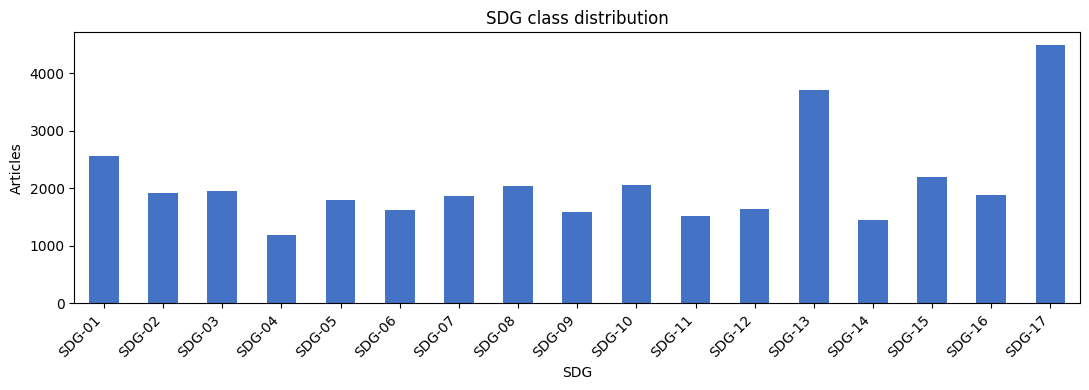

In [ ]:
# Class distribution
counts = df[sdg_columns].fillna(False).astype(bool).sum().sort_index()
plot_counts(counts, "SDG class distribution", "SDG", "Articles")

In [ ]:
# Article text length
text_stats(df, "text")


Text field: text


,characters,words
count,9172.000000,9172.000000
mean,4575.852704,674.728631
std,2550.071544,378.901731
min,458.000000,82.000000
25%,2938.750000,429.000000
50%,3915.500000,574.000000
75%,5457.250000,807.000000
max,33419.000000,4656.000000


Empty text rows: 0


In [ ]:
# Articles by year
years = pd.to_datetime(df["date"], errors="coerce").dt.year
display(years.value_counts().sort_index().rename_axis("year").to_frame("rows"))

,rows
year,
2008.0,1
2010.0,2
2011.0,12
2012.0,231
2013.0,608
2014.0,633
2015.0,633
2016.0,1220
2017.0,1334
